In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('../data/processed/gurgaon_properties_outlier_treated.csv')

In [4]:
df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,0,house,house number b-34,sector 5,0.80,8889.0,900.0,Plot area 900(83.61 sq.m.)Built Up area: 900 s...,2,2,1,1.0,NaN,Old Property,NaN,900.0,NaN,0,0,0,0,0,1,0,450.000000
1,1,flat,godrej summit,sector 104,1.20,8299.0,1446.0,Carpet area: 1446 (134.34 sq.m.),3,2,3+,16.0,NaN,Relatively New,NaN,NaN,1446.0,1,0,0,1,0,0,142,482.000000
2,2,flat,residency grand,sector 52,5.00,7692.0,6500.0,Carpet area: 5200 (483.1 sq.m.),5,7,3+,1.0,East,Moderately Old,NaN,NaN,5200.0,0,1,0,1,0,1,77,1300.000000
3,3,house,independent,sector 22,4.75,20068.0,2367.0,Plot area 263(219.9 sq.m.)Built Up area: 261 s...,7,5,3+,3.0,South-West,Old Property,NaN,261.0,259.0,0,0,0,1,1,0,49,338.142857
4,4,flat,signature global park,sohna road,0.56,6813.0,822.0,Carpet area: 822 (76.37 sq.m.),2,2,3,3.0,South,New Property,NaN,NaN,822.0,0,0,0,0,0,1,81,411.000000


In [5]:
df.isnull().sum()

Unnamed: 0                0
property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1968
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

### Built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

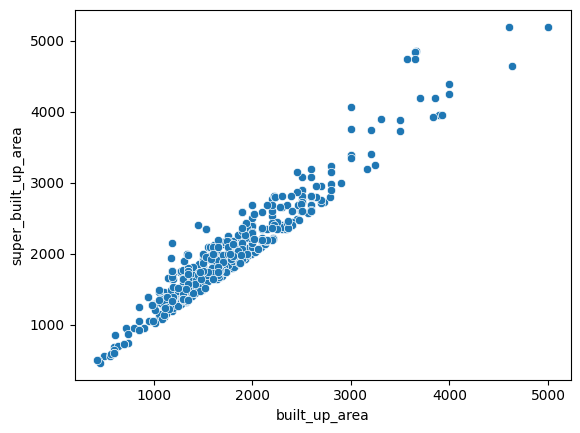

In [6]:
sns.scatterplot(x = df['built_up_area'],y= df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

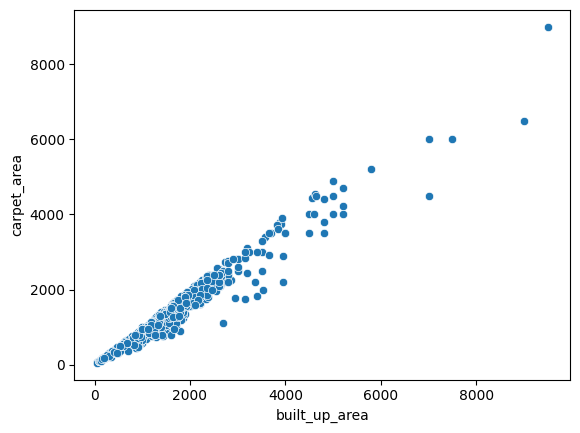

In [7]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [8]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())).sum()

np.int64(0)

In [9]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [10]:
all_present_df.head()[['super_built_up_area','built_up_area','carpet_area']]

,super_built_up_area,built_up_area,carpet_area
5,4739.0,3573.33,3400.0
10,1755.0,1600.00,1400.0
20,2215.0,1900.00,1700.0
22,2588.0,1900.00,1877.0
28,1776.0,1576.00,1476.0


In [11]:
all_present_df.shape

(531, 25)

In [12]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [13]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [14]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [15]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [16]:
sbc_df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
7,7,flat,eldeco accolade,sohna road,0.95,6543.0,1452.0,Super Built up area 1452(134.9 sq.m.)Carpet ar...,2,2,3+,6.0,East,New Property,1452.00,NaN,849.0,1,0,0,0,0,0,56,726.000000
12,12,flat,vatika the seven lamps,sector 82,0.89,8847.0,1006.0,Super Built up area 1428.08(132.67 sq.m.)Carpe...,2,2,2,14.0,East,Relatively New,1428.08,NaN,1000.0,1,0,0,0,0,0,129,503.000000
24,25,flat,emaar mgf emerald estate,sector 65,1.75,12545.0,1395.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,10.0,North-East,Relatively New,1395.00,NaN,809.0,0,1,0,0,0,0,124,465.000000
33,34,flat,m3m golfestate,sector 65,6.15,18287.0,3363.0,Super Built up area 3363(312.43 sq.m.)Carpet a...,3,3,3,23.0,NaN,Moderately Old,3363.00,NaN,2710.0,1,1,0,0,0,0,60,1121.000000
34,35,flat,alpha corp gurgaonone,sector 84,1.49,7590.0,1963.0,Super Built up area 1963(182.37 sq.m.)Carpet a...,3,3,3,6.0,South-East,Relatively New,1963.00,NaN,1700.0,0,1,0,0,0,1,28,654.333333


In [17]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\Predator\AppData\Local\Temp\ipykernel_19744\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\Predator\AppData\Local\Temp\ipykernel_19744\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versu

In [18]:
df.update(sbc_df)

In [19]:
df.isnull().sum()

Unnamed: 0                0
property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1547
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [20]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [21]:
sb_df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
16,17,flat,kashish manor one,sector 111,1.65,7097.0,2325.0,Super Built up area 2325(216 sq.m.),3,4,3+,14.0,NaN,Under Construction,2325.0,NaN,NaN,0,1,0,0,1,1,8,775.000000
18,19,flat,tulip violet,sector 69,1.70,8433.0,2016.0,Super Built up area 2010(186.74 sq.m.),4,4,2,10.0,South,New Property,2010.0,NaN,NaN,0,0,0,0,0,1,125,504.000000
21,22,flat,ss residency,sector 12,0.53,4818.0,1100.0,Super Built up area 1100(102.19 sq.m.),3,3,2,2.0,NaN,Relatively New,1100.0,NaN,NaN,0,0,0,0,0,0,14,366.666667
23,24,flat,chd avenue,sector 71,1.35,5745.0,2350.0,Super Built up area 2350(218.32 sq.m.),4,4,3,8.0,North-West,Moderately Old,2350.0,NaN,NaN,0,1,0,0,0,1,26,587.500000
25,26,flat,unitech the palms,sector 41,2.75,16768.0,1640.0,Super Built up area 1640(152.36 sq.m.),3,3,2,14.0,NaN,Old Property,1640.0,NaN,NaN,0,0,0,0,0,2,79,546.666667


In [22]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\Predator\AppData\Local\Temp\ipykernel_19744\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\Predator\AppData\Local\Temp\ipykernel_19744\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fill

In [23]:
df.update(sb_df)

In [24]:
df.isnull().sum()

Unnamed: 0                0
property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area           672
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [25]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [26]:
c_df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,1,flat,godrej summit,sector 104,1.20,8299.0,1446.0,Carpet area: 1446 (134.34 sq.m.),3,2,3+,16.0,NaN,Relatively New,NaN,NaN,1446.0,1,0,0,1,0,0,142,482.0
2,2,flat,residency grand,sector 52,5.00,7692.0,6500.0,Carpet area: 5200 (483.1 sq.m.),5,7,3+,1.0,East,Moderately Old,NaN,NaN,5200.0,0,1,0,1,0,1,77,1300.0
4,4,flat,signature global park,sohna road,0.56,6813.0,822.0,Carpet area: 822 (76.37 sq.m.),2,2,3,3.0,South,New Property,NaN,NaN,822.0,0,0,0,0,0,1,81,411.0
6,6,flat,signature global solera,sector 107,0.28,5833.0,480.0,Carpet area: 489 (45.43 sq.m.),2,2,2,0.0,North-East,Relatively New,NaN,NaN,489.0,0,0,0,0,0,1,45,240.0
11,11,flat,smart world orchard,sector 61,1.58,13739.0,1150.0,Carpet area: 1150 (106.84 sq.m.),2,2,2,3.0,South,New Property,NaN,NaN,1150.0,1,0,0,0,0,1,15,575.0


In [27]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\Predator\AppData\Local\Temp\ipykernel_19744\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\Predator\AppData\Local\Temp\ipykernel_19744\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df

In [28]:
df.update(c_df)

In [29]:
df.isnull().sum()

Unnamed: 0                0
property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area             0
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

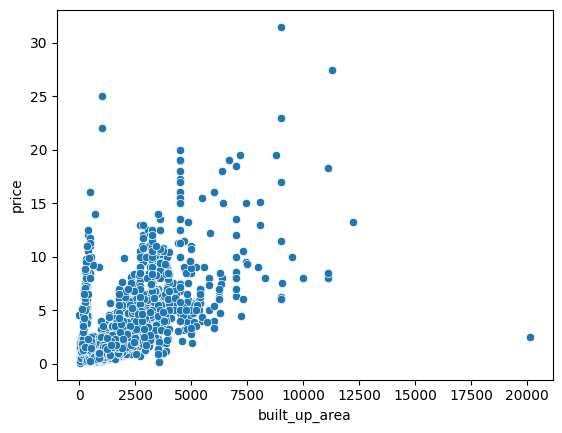

In [30]:
sns.scatterplot(x = df['built_up_area'], y = df['price'])

In [31]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [32]:
anamoly_df.sample(5)

,price,area,built_up_area
2656,3.50,1722.0,1712.0
1058,2.55,1860.0,1600.0
2120,9.25,5580.0,630.0
934,12.00,3240.0,400.0
1073,3.95,2343.0,1900.0


In [33]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [34]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

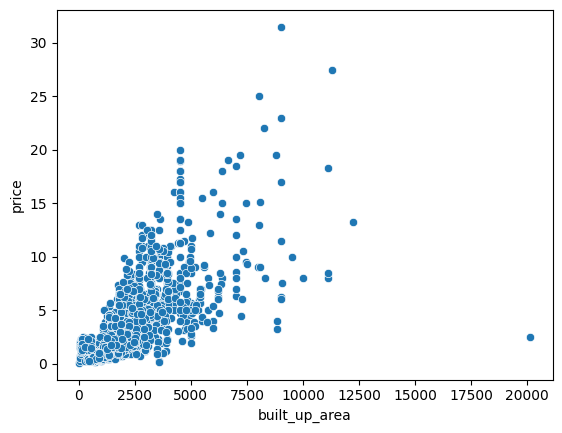

In [35]:
sns.scatterplot(x = df['built_up_area'], y =df['price'])

In [36]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [37]:
df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,house,house number b-34,sector 5,0.80,8889.0,2,2,1,1.0,NaN,Old Property,900.0,0,0,0,0,0,1,0
1,1,flat,godrej summit,sector 104,1.20,8299.0,3,2,3+,16.0,NaN,Relatively New,1607.0,1,0,0,1,0,0,142
2,2,flat,residency grand,sector 52,5.00,7692.0,5,7,3+,1.0,East,Moderately Old,5778.0,0,1,0,1,0,1,77
3,3,house,independent,sector 22,4.75,20068.0,7,5,3+,3.0,South-West,Old Property,2367.0,0,0,0,1,1,0,49
4,4,flat,signature global park,sohna road,0.56,6813.0,2,2,3,3.0,South,New Property,913.0,0,0,0,0,0,1,81


In [38]:
df.isnull().sum()

Unnamed: 0            0
property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floorNum

In [39]:
df[df['floorNum'].isnull()]

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
164,167,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,1,0
435,449,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,1,9
538,554,house,independent,sector 26,4.60,12198.0,4,4,3+,NaN,NaN,Old Property,3771.0,0,0,0,0,0,1,28
673,698,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,585.0,0,0,0,0,0,1,0
1174,1227,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,1,0
1194,1247,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,0,114
1296,1355,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,1,0
1613,1693,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,1,0
1638,1718,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,1,0
2351,2479,house,independent,sector 25,13.00,45710.0,6,8,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,2,0


In [40]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [41]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\Predator\AppData\Local\Temp\ipykernel_19744\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [42]:
df.isnull().sum()

Unnamed: 0            0
property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [43]:
1011/df.shape[0]

0.2843881856540084

### facing

<Axes: ylabel='count'>

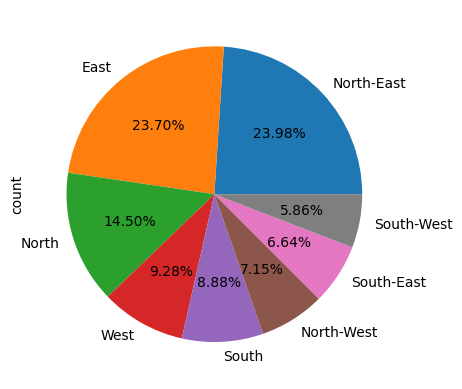

In [44]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [45]:
df.drop(columns=['facing'],inplace=True)

In [46]:
df.sample(5)

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1008,1048,flat,ramsons kshitij,sector 95,0.35,5495.0,2,2,0,5.0,Undefined,637.0,0,0,0,0,0,1,0
946,983,flat,indiabulls enigma,sector 110,3.60,10588.0,4,5,3,7.0,Relatively New,3077.0,0,1,0,0,0,1,165
2208,2328,flat,mapsko casa bella,sector 82,1.30,6379.0,4,4,3+,1.0,Relatively New,1774.0,0,1,0,0,0,1,130
1980,2085,house,independent,sector 25,10.50,29022.0,5,5,3,3.0,Moderately Old,3618.0,1,1,0,1,0,1,42
2791,2960,flat,orchid petals,sector 49,1.90,10526.0,3,3,3,2.0,Old Property,1600.0,0,0,0,0,1,0,49


In [47]:
df.isnull().sum()

Unnamed: 0         0
property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [48]:
df[df['society'].isnull()]

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2504,2645,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,1,0


In [49]:
df.drop(index=[2504],inplace=True)

In [50]:
df.isnull().sum()

Unnamed: 0         0
property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [51]:
df['agePossession'].value_counts()

agePossession
Relatively New        1605
New Property           557
Moderately Old         545
Old Property           293
Undefined              291
Under Construction     263
Name: count, dtype: int64

In [52]:
df[df['agePossession'] == 'Undefined']

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
8,8,house,independent,sector 9,1.65,18333.0,2,3,0,3.0,Undefined,900.0,0,0,0,0,0,1,0
9,9,flat,signature global park,sohna road,0.87,7190.0,3,2,3,4.0,Undefined,1210.0,0,0,0,0,0,1,58
17,18,flat,lavanya apartments,sector 81,0.90,5056.0,3,3,0,7.0,Undefined,1780.0,0,0,0,0,0,1,0
49,50,flat,smart world orchard,sector 61,2.50,16139.0,3,3,1,1.0,Undefined,1549.0,0,0,0,0,0,1,61
55,56,flat,mrg skyline,sector 106,1.82,13392.0,3,2,2,4.0,Undefined,1359.0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3506,3747,flat,aipl peaceful homes,sector 70a,2.75,12791.0,3,3,3+,14.0,Undefined,2150.0,0,0,0,0,0,1,0
3512,3755,flat,whiteland blissville,sector 76,1.92,11497.0,3,3,2,2.0,Undefined,1672.0,0,0,0,0,0,1,61
3542,3788,flat,ansal housing highland park,sector 103,0.80,5878.0,2,2,2,9.0,Undefined,1361.0,0,0,0,0,0,1,0
3543,3789,house,independent,sector 13,2.25,6944.0,10,10,2,1.0,Undefined,400.0,0,0,0,0,0,1,0


In [53]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [54]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [55]:
df['agePossession'].value_counts()

agePossession
Relatively New        1717
New Property           597
Moderately Old         583
Old Property           326
Under Construction     277
Undefined               54
Name: count, dtype: int64

In [56]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [57]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [58]:
df['agePossession'].value_counts()

agePossession
Relatively New        1727
New Property           598
Moderately Old         590
Old Property           329
Under Construction     277
Undefined               33
Name: count, dtype: int64

In [59]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [60]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [61]:
df['agePossession'].value_counts()

agePossession
Relatively New        1729
Moderately Old         621
New Property           598
Old Property           329
Under Construction     277
Name: count, dtype: int64

In [62]:
df.isnull().sum()

Unnamed: 0         0
property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [63]:
df.drop('Unnamed: 0' , axis=1 , inplace=True)

In [64]:
df.to_csv('../data/processed/gurgaon_properties_missing_value_imputation.csv',index=False)

In [65]:
df.shape

(3554, 18)